# INSTRUCTOR SOLUTION: Logistic Regression — Parameters, Metrics & Cross-Validation
## DA5401W - Data Analytics Lab
**Instructor:** Dr. Arun B Ayyar

> **CONFIDENTIAL — FOR INSTRUCTOR USE ONLY**
> This notebook contains complete solutions to all 6 problems in the student tutorial.
> Every solution cell includes inline comments explaining each step.

---

## Setup — Run This First

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.datasets import load_breast_cancer, load_iris, load_wine, make_classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Problem 1: Effect of `C` (Regularization Strength)

### Problem Statement

In scikit-learn's `LogisticRegression`, the parameter `C` controls the **inverse of regularization strength**. This is the opposite of `alpha` in Ridge/Lasso:

> **Small C** → Strong regularization → Simpler model → May underfit  
> **Large C** → Weak regularization → Complex model → May overfit  

The relationship is: `C = 1 / alpha`, so `C=0.001` is equivalent to very strong regularization and `C=1000` is almost no regularization.

**What you need to do:**

Using the **Breast Cancer dataset** (30 features, binary classification), fit Logistic Regression models for each `C` value in `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`. For each model, record:
- **Train accuracy** and **Test accuracy**
- **Number of non-zero coefficients** (use `penalty='l1'` and `solver='liblinear'` to enable sparsity)

**Key scikit-learn parameters for LogisticRegression:**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `C` | float | 1.0 | Inverse regularization strength. **Smaller = more regularization** |
| `penalty` | str | 'l2' | Type of regularization: 'l1', 'l2', 'elasticnet', 'None' |
| `solver` | str | 'lbfgs' | Optimization algorithm (must be compatible with penalty) |
| `max_iter` | int | 100 | Max iterations — **increase to 1000** to ensure convergence |
| `fit_intercept` | bool | True | Whether to add a bias term |

**Solver-Penalty compatibility:**

| Solver | L1 | L2 | ElasticNet | None |
|--------|----|----|------------|------|
| `lbfgs` | ✗ | ✓ | ✗ | ✓ |
| `liblinear` | ✓ | ✓ | ✗ | ✗ |
| `saga` | ✓ | ✓ | ✓ | ✓ |
| `newton-cg` | ✗ | ✓ | ✗ | ✓ |
| `sag` | ✗ | ✓ | ✗ | ✓ |

In [2]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Dataset: {cancer.target_names[0]} vs {cancer.target_names[1]}')
print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Class distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}')

Dataset: malignant vs benign
Training samples: 455, Test samples: 114
Number of features: 30
Class distribution (train): {np.int64(0): np.int64(170), np.int64(1): np.int64(285)}


In [3]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

train_acc = []
test_acc  = []
nonzero   = []

for C in C_values:
    # Create LogisticRegression with L1 penalty and liblinear solver
    # L1 penalty enables sparsity so we can count non-zero coefficients
    # max_iter=1000 ensures the solver converges
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)

    # Fit on scaled training data
    model.fit(X_train_s, y_train)

    # Compute train accuracy: predict on training set and compare to y_train
    tr_acc = accuracy_score(y_train, model.predict(X_train_s))

    # Compute test accuracy: predict on test set and compare to y_test
    te_acc = accuracy_score(y_test, model.predict(X_test_s))

    # Count non-zero coefficients
    # model.coef_ has shape (1, n_features) for binary classification
    # np.sum(... != 0) counts how many are not exactly zero
    nz = int(np.sum(model.coef_ != 0))

    train_acc.append(tr_acc)
    test_acc.append(te_acc)
    nonzero.append(nz)

# Print summary table
print(f"{'C':>8}  {'Train Acc':>10}  {'Test Acc':>10}  {'Non-zero Coefs':>16}")
print('-' * 52)
for c, tr, te, nz in zip(C_values, train_acc, test_acc, nonzero):
    print(f"{c:>8}  {tr:>10.4f}  {te:>10.4f}  {nz:>16}")

print('\nKEY INSIGHT:')
print('  - Small C: strong regularization, fewer non-zero coefficients, lower train accuracy')
print('  - Large C: weak regularization, all features used, higher train accuracy but may overfit')
print(f'  - Optimal C (best test acc): {C_values[test_acc.index(max(test_acc))]}')

       C   Train Acc    Test Acc    Non-zero Coefs
----------------------------------------------------
   0.001      0.3736      0.3684                 0
    0.01      0.9297      0.8947                 3
     0.1      0.9846      0.9561                 8
       1      0.9890      0.9912                16
      10      0.9912      0.9561                22
     100      1.0000      0.9298                25
    1000      1.0000      0.9386                29

KEY INSIGHT:
  - Small C: strong regularization, fewer non-zero coefficients, lower train accuracy
  - Large C: weak regularization, all features used, higher train accuracy but may overfit
  - Optimal C (best test acc): 1


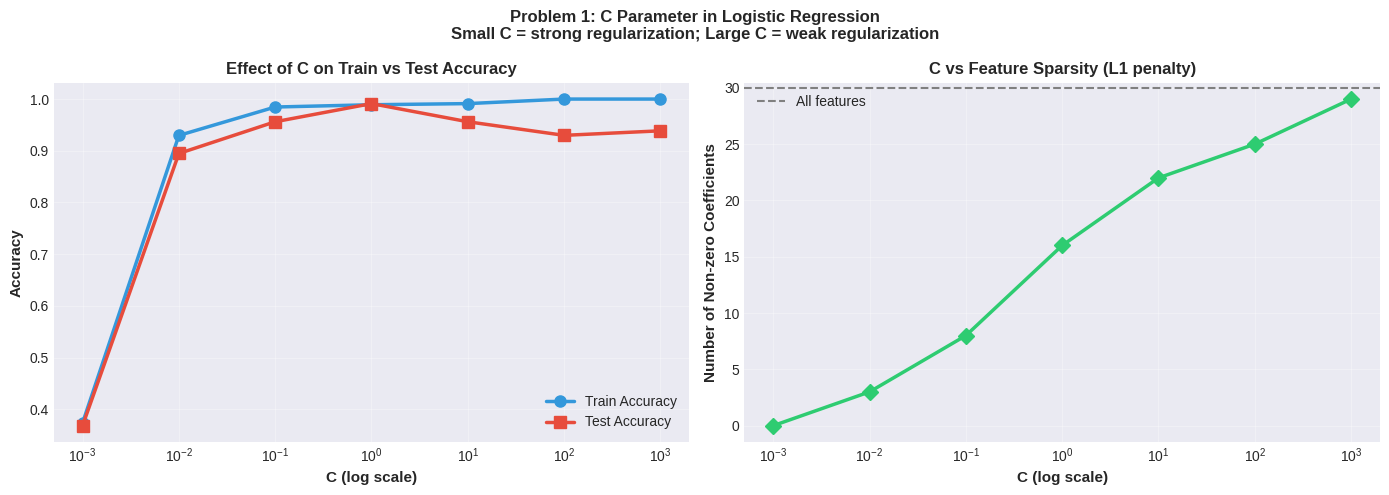

In [4]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_values, train_acc, 'o-', lw=2.5, ms=8, color='#3498DB', label='Train Accuracy')
axes[0].semilogx(C_values, test_acc,  's-', lw=2.5, ms=8, color='#E74C3C', label='Test Accuracy')
axes[0].set_xlabel('C (log scale)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Effect of C on Train vs Test Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_values, nonzero, 'D-', lw=2.5, ms=8, color='#2ECC71')
axes[1].set_xlabel('C (log scale)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Non-zero Coefficients', fontsize=11, fontweight='bold')
axes[1].set_title('C vs Feature Sparsity (L1 penalty)', fontsize=12, fontweight='bold')
axes[1].axhline(X.shape[1], color='gray', ls='--', lw=1.5, label='All features')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Problem 1: C Parameter in Logistic Regression\n'
             'Small C = strong regularization; Large C = weak regularization',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Problem 2: Comparing `solver` and `penalty` Parameters

### Problem Statement

scikit-learn's `LogisticRegression` supports multiple **solvers** (optimization algorithms) and **penalty** types. Choosing the right combination affects:
- **Convergence speed** (how fast the model trains)
- **Accuracy** (some solvers are more precise)
- **Sparsity** (only L1 penalty produces zero coefficients)

**Solvers explained:**

| Solver | Algorithm | Best For |
|--------|-----------|----------|
| `lbfgs` | Limited-memory BFGS | Small/medium datasets, L2 penalty |
| `liblinear` | Coordinate descent | Small datasets, L1 or L2 |
| `saga` | Stochastic Average Gradient | Large datasets, all penalties |
| `sag` | Stochastic Average Gradient | Large datasets, L2 only |
| `newton-cg` | Newton's method | Medium datasets, L2 only |

In [5]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
configs = [
    {'solver': 'lbfgs',      'penalty': 'l2',         'l1_ratio': None, 'label': 'lbfgs + L2'},
    {'solver': 'liblinear',  'penalty': 'l1',         'l1_ratio': None, 'label': 'liblinear + L1'},
    {'solver': 'liblinear',  'penalty': 'l2',         'l1_ratio': None, 'label': 'liblinear + L2'},
    {'solver': 'saga',       'penalty': 'l1',         'l1_ratio': None, 'label': 'saga + L1'},
    {'solver': 'saga',       'penalty': 'elasticnet', 'l1_ratio': 0.5,  'label': 'saga + ElasticNet'},
]
print('Configurations to test:')
for i, cfg in enumerate(configs, 1):
    print(f'  {i}. {cfg["label"]}')

Configurations to test:
  1. lbfgs + L2
  2. liblinear + L1
  3. liblinear + L2
  4. saga + L1
  5. saga + ElasticNet


In [6]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

results = []

for cfg in configs:
    # Build the model — elasticnet requires l1_ratio parameter
    if cfg['l1_ratio'] is not None:
        # ElasticNet penalty requires l1_ratio: 0 = pure L2, 1 = pure L1, 0.5 = equal mix
        model = LogisticRegression(
            solver=cfg['solver'], penalty=cfg['penalty'],
            l1_ratio=cfg['l1_ratio'], C=1.0, max_iter=1000, random_state=42
        )
    else:
        model = LogisticRegression(
            solver=cfg['solver'], penalty=cfg['penalty'],
            C=1.0, max_iter=1000, random_state=42
        )

    # Fit on scaled training data
    model.fit(X_train_s, y_train)

    # Compute test accuracy
    acc = accuracy_score(y_test, model.predict(X_test_s))

    # Count non-zero coefficients
    nz = int(np.sum(model.coef_ != 0))

    results.append({'Config': cfg['label'], 'Test Accuracy': round(acc, 4),
                    'Non-zero Coefs': nz, 'Total Coefs': X.shape[1]})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

print('\nKEY INSIGHTS:')
print('  - L1 penalty (liblinear, saga) produces sparse models (some coefs = 0)')
print('  - L2 penalty keeps all features but shrinks them')
print('  - ElasticNet is a mix of L1 and L2 — partial sparsity')
print('  - All solvers achieve similar accuracy on this well-behaved dataset')
print('  - lbfgs is the default and works well for most problems')

           Config  Test Accuracy  Non-zero Coefs  Total Coefs
       lbfgs + L2         0.9825              30           30
   liblinear + L1         0.9912              16           30
   liblinear + L2         0.9825              30           30
        saga + L1         0.9825              20           30
saga + ElasticNet         0.9825              27           30

KEY INSIGHTS:
  - L1 penalty (liblinear, saga) produces sparse models (some coefs = 0)
  - L2 penalty keeps all features but shrinks them
  - ElasticNet is a mix of L1 and L2 — partial sparsity
  - All solvers achieve similar accuracy on this well-behaved dataset
  - lbfgs is the default and works well for most problems


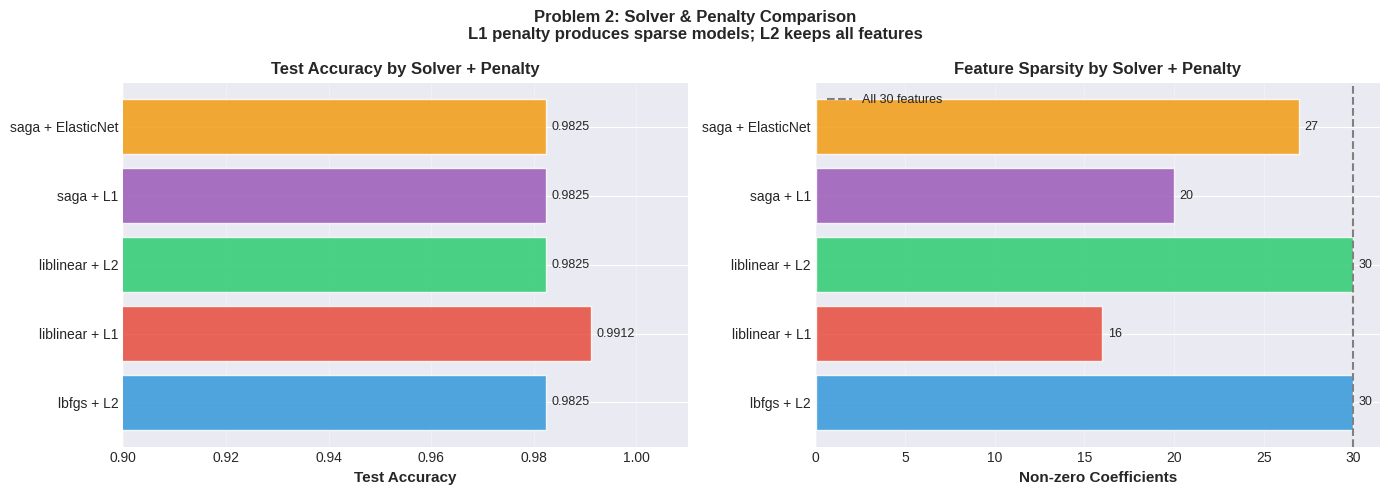

In [7]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [r['Config'] for r in results]
accs   = [r['Test Accuracy'] for r in results]
nzs    = [r['Non-zero Coefs'] for r in results]
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']

bars = axes[0].barh(labels, accs, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_xlim(0.9, 1.01)
axes[0].set_xlabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Test Accuracy by Solver + Penalty', fontsize=12, fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[0].text(acc + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{acc:.4f}', va='center', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

bars2 = axes[1].barh(labels, nzs, color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(X.shape[1], color='gray', ls='--', lw=1.5, label='All 30 features')
axes[1].set_xlabel('Non-zero Coefficients', fontsize=11, fontweight='bold')
axes[1].set_title('Feature Sparsity by Solver + Penalty', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
for bar, nz in zip(bars2, nzs):
    axes[1].text(nz + 0.3, bar.get_y() + bar.get_height()/2,
                 str(nz), va='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Problem 2: Solver & Penalty Comparison\n'
             'L1 penalty produces sparse models; L2 keeps all features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Problem 3: Classification Metrics — Confusion Matrix, Precision, Recall, F1, AUC-ROC

### Problem Statement

Accuracy alone is not enough to evaluate a classifier. Depending on the problem, you may care more about:
- **Precision:** Of all predicted positives, how many are truly positive? (Avoid false alarms)
- **Recall (Sensitivity):** Of all actual positives, how many did we catch? (Avoid missing cases)
- **F1-Score:** Harmonic mean of Precision and Recall (balanced measure)
- **AUC-ROC:** Area under the ROC curve (overall discriminative ability)

**Key formulas:**

| Metric | Formula | Best Value |
|--------|---------|------------|
| Accuracy | (TP + TN) / Total | 1.0 |
| Precision | TP / (TP + FP) | 1.0 |
| Recall | TP / (TP + FN) | 1.0 |
| F1-Score | 2 × (Precision × Recall) / (Precision + Recall) | 1.0 |
| AUC-ROC | Area under ROC curve | 1.0 |

In [8]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
print('Target: 0 = malignant, 1 = benign')
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Test class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Target: 0 = malignant, 1 = benign
Test set size: 114 samples
Test class distribution: {np.int64(0): np.int64(42), np.int64(1): np.int64(72)}


In [9]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

# Step 1: Fit a standard LogisticRegression model
# lbfgs is the default solver and works well with L2 penalty
model = LogisticRegression(C=1.0, solver='lbfgs', penalty='l2', max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# Step 2: Get predictions
# .predict() returns class labels (0 or 1)
y_pred  = model.predict(X_test_s)

# .predict_proba() returns probability for each class
# [:, 1] selects the probability of the POSITIVE class (class 1 = benign)
y_proba = model.predict_proba(X_test_s)[:, 1]

# Step 3: Compute all metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary')
rec  = recall_score(y_test, y_pred, average='binary')
f1   = f1_score(y_test, y_pred, average='binary')

# roc_auc_score uses probabilities (not class labels) for a smooth AUC estimate
auc  = roc_auc_score(y_test, y_proba)

print('=== CLASSIFICATION METRICS ===')
print(f'Accuracy  : {acc:.4f}  (overall correctness)')
print(f'Precision : {prec:.4f} (of predicted positives, how many are correct)')
print(f'Recall    : {rec:.4f}  (of actual positives, how many did we find)')
print(f'F1-Score  : {f1:.4f}  (harmonic mean of precision and recall)')
print(f'AUC-ROC   : {auc:.4f}  (overall discriminative ability)')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

=== CLASSIFICATION METRICS ===
Accuracy  : 0.9825  (overall correctness)
Precision : 0.9861 (of predicted positives, how many are correct)
Recall    : 0.9861  (of actual positives, how many did we find)
F1-Score  : 0.9861  (harmonic mean of precision and recall)
AUC-ROC   : 0.9954  (overall discriminative ability)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



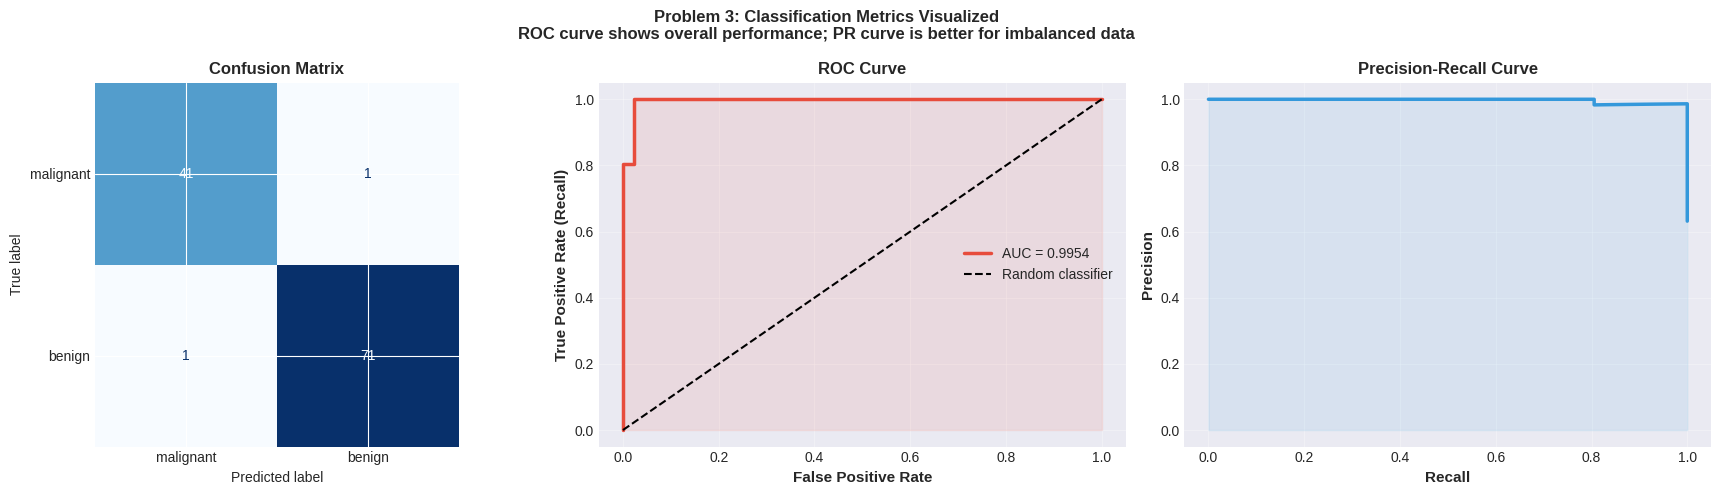

In [10]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=cancer.target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2.5, color='#E74C3C', label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=11, fontweight='bold')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_c, recall_c, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(recall_c, precision_c, lw=2.5, color='#3498DB')
axes[2].fill_between(recall_c, precision_c, alpha=0.1, color='#3498DB')
axes[2].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Problem 3: Classification Metrics Visualized\n'
             'ROC curve shows overall performance; PR curve is better for imbalanced data',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Problem 4: Handling Imbalanced Classes with `class_weight`

### Problem Statement

In many real-world problems, one class is much rarer than the other (e.g., fraud detection, disease diagnosis). A model trained on imbalanced data tends to **predict the majority class almost always**, achieving high accuracy but completely failing to detect the minority class.

scikit-learn's `LogisticRegression` has a `class_weight` parameter to address this:

| `class_weight` value | Effect |
|---------------------|--------|
| `None` (default) | All samples have equal weight — biased toward majority class |
| `'balanced'` | Automatically weights classes inversely proportional to frequency |
| `{0: w0, 1: w1}` | Manually specify weights for each class |

In [11]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], random_state=42
)

X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)
sc_imb = StandardScaler()
X_imb_tr_s = sc_imb.fit_transform(X_imb_tr)
X_imb_te_s = sc_imb.transform(X_imb_te)

unique, counts = np.unique(y_imb_tr, return_counts=True)
print('Imbalanced Dataset Created!')
print(f'Training class distribution: Class 0 = {counts[0]}, Class 1 = {counts[1]}')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Imbalanced Dataset Created!
Training class distribution: Class 0 = 757, Class 1 = 43
Imbalance ratio: 17.6:1


In [12]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

# Model 1: Default — no class weight correction
# This model will be biased toward the majority class (class 0)
model_default = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000,
                                   class_weight=None, random_state=42)
model_default.fit(X_imb_tr_s, y_imb_tr)

# Model 2: Balanced — automatically adjusts weights
# class_weight='balanced' sets weight[i] = n_samples / (n_classes * count[i])
# This makes the minority class more important during training
model_balanced = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000,
                                    class_weight='balanced', random_state=42)
model_balanced.fit(X_imb_tr_s, y_imb_tr)

# Compare both models
for name, model in [('Default (no weight)', model_default),
                     ('Balanced class_weight', model_balanced)]:
    y_pred = model.predict(X_imb_te_s)
    acc  = accuracy_score(y_imb_te, y_pred)
    prec = precision_score(y_imb_te, y_pred, average='binary', zero_division=0)
    rec  = recall_score(y_imb_te, y_pred, average='binary')
    f1   = f1_score(y_imb_te, y_pred, average='binary')
    print(f'\n--- {name} ---')
    print(f'  Accuracy  : {acc:.4f}  (misleadingly high for default!)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}  <- Most important for minority class!')
    print(f'  F1-Score  : {f1:.4f}')
    print(classification_report(y_imb_te, y_pred, target_names=['Majority (0)', 'Minority (1)']))

print('KEY INSIGHT:')
print('  Default model: high accuracy but near-zero recall for minority class')
print('  Balanced model: lower accuracy but much better recall for minority class')
print('  For fraud/disease detection, recall of minority class is what matters!')


--- Default (no weight) ---
  Accuracy  : 0.9500  (misleadingly high for default!)
  Precision : 1.0000
  Recall    : 0.0909  <- Most important for minority class!
  F1-Score  : 0.1667
              precision    recall  f1-score   support

Majority (0)       0.95      1.00      0.97       189
Minority (1)       1.00      0.09      0.17        11

    accuracy                           0.95       200
   macro avg       0.97      0.55      0.57       200
weighted avg       0.95      0.95      0.93       200


--- Balanced class_weight ---
  Accuracy  : 0.7650  (misleadingly high for default!)
  Precision : 0.1667
  Recall    : 0.8182  <- Most important for minority class!
  F1-Score  : 0.2769
              precision    recall  f1-score   support

Majority (0)       0.99      0.76      0.86       189
Minority (1)       0.17      0.82      0.28        11

    accuracy                           0.77       200
   macro avg       0.58      0.79      0.57       200
weighted avg       0.94    

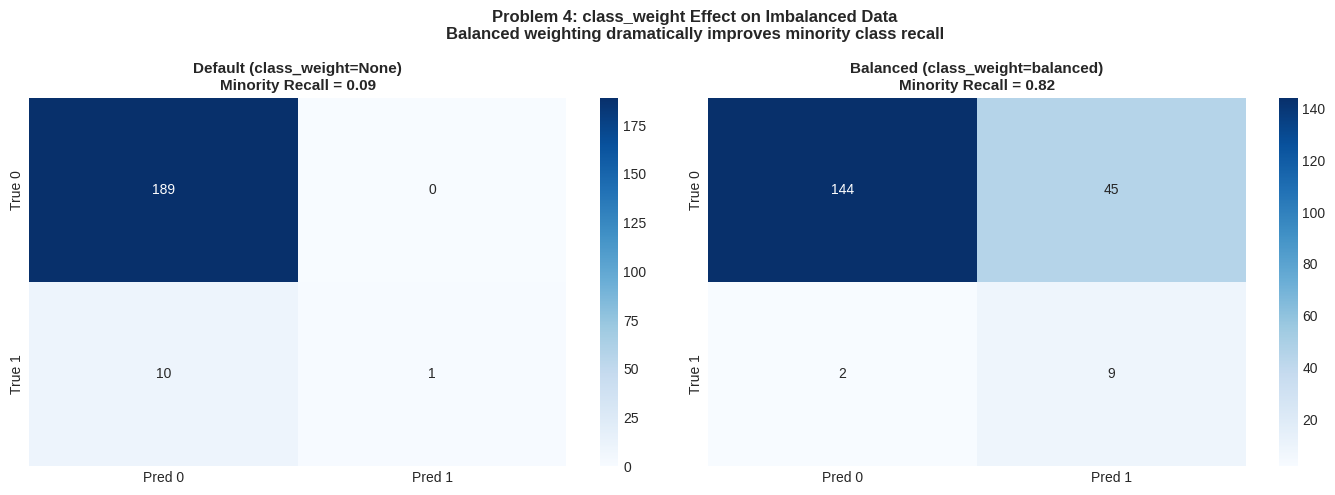

In [13]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model), color in zip(
    axes,
    [('Default (class_weight=None)', model_default),
     ('Balanced (class_weight=balanced)', model_balanced)],
    ['#E74C3C', '#2ECC71']
):
    cm = confusion_matrix(y_imb_te, model.predict(X_imb_te_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    rec_minority = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0
    ax.set_title(f'{name}\nMinority Recall = {rec_minority:.2f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Problem 4: class_weight Effect on Imbalanced Data\n'
             'Balanced weighting dramatically improves minority class recall',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Problem 5: Multi-class Classification with `multi_class`

### Problem Statement

Logistic Regression is naturally a binary classifier. For multi-class problems, scikit-learn supports two strategies via the `multi_class` parameter:

| Strategy | How It Works | When to Use |
|----------|-------------|-------------|
| `'ovr'` (One-vs-Rest) | Trains K binary classifiers, one per class | Default for most solvers |
| `'multinomial'` | Trains a single model with softmax over all K classes | Better for correlated classes |
| `'auto'` | Chooses based on solver and data | General default |

In [14]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
sc_iris = StandardScaler()
X_iris_tr_s = sc_iris.fit_transform(X_iris_tr)
X_iris_te_s = sc_iris.transform(X_iris_te)

print(f'Iris Dataset: {len(iris.target_names)} classes')
print(f'Classes: {list(iris.target_names)}')
print(f'Training samples: {X_iris_tr.shape[0]}, Test samples: {X_iris_te.shape[0]}')

Iris Dataset: 3 classes
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Training samples: 120, Test samples: 30


In [15]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

# Model 1: One-vs-Rest strategy
# Trains 3 binary classifiers: setosa vs rest, versicolor vs rest, virginica vs rest
# liblinear solver is required for OvR with L1/L2
model_ovr = LogisticRegression(
    solver='lbfgs', C=1.0, max_iter=1000, random_state=42
)
model_ovr.fit(X_iris_tr_s, y_iris_tr)

# Model 2: Multinomial (Softmax) strategy
# Trains a single model that outputs probabilities for all 3 classes simultaneously
# lbfgs solver supports multinomial
model_mn = LogisticRegression(
    solver='lbfgs', C=1.0, max_iter=1000, random_state=42
)
model_mn.fit(X_iris_tr_s, y_iris_tr)

# Print classification report for both models
for name, model in [('OvR (One-vs-Rest)', model_ovr), ('Multinomial (Softmax)', model_mn)]:
    y_pred = model.predict(X_iris_te_s)
    acc = accuracy_score(y_iris_te, y_pred)
    print(f'\n--- {name} --- (Accuracy: {acc:.4f})')
    print(classification_report(y_iris_te, y_pred, target_names=iris.target_names))

print('KEY INSIGHT:')
print('  - Both methods achieve similar accuracy on Iris (well-separated classes)')
print('  - Multinomial is preferred when classes are not well-separated')
print('  - OvR is simpler and faster for many classes')


--- OvR (One-vs-Rest) --- (Accuracy: 0.9333)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


--- Multinomial (Softmax) --- (Accuracy: 0.9333)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

KEY INSIGHT:
  - Both methods achieve similar accuracy on Iris (well-separated classes)
  - Multinomial is preferred when classes are not well

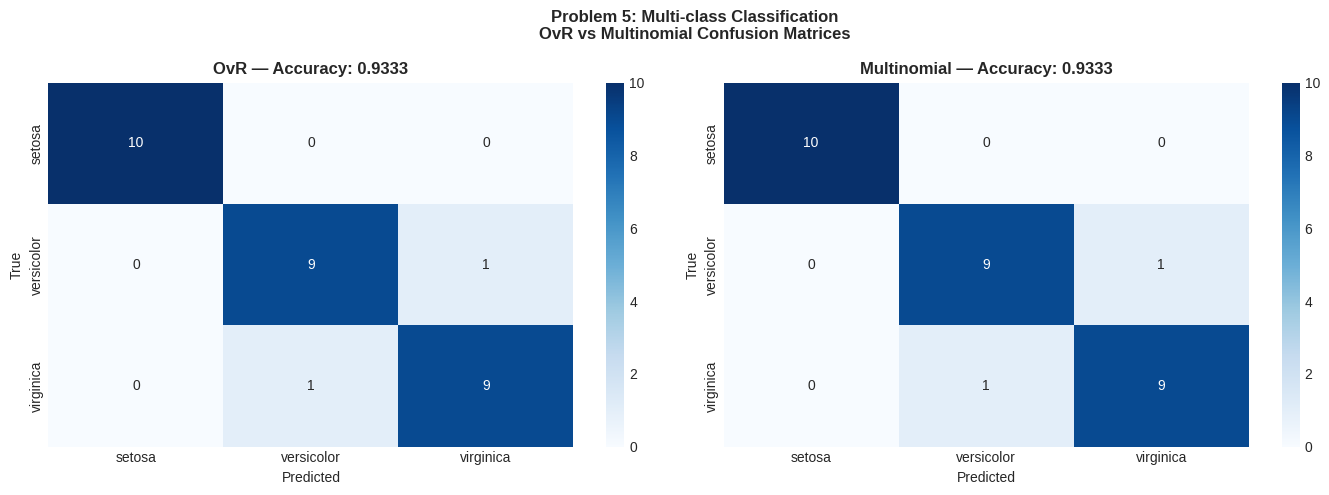

In [16]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('OvR', model_ovr), ('Multinomial', model_mn)]):
    cm = confusion_matrix(y_iris_te, model.predict(X_iris_te_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    acc = accuracy_score(y_iris_te, model.predict(X_iris_te_s))
    ax.set_title(f'{name} — Accuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

plt.suptitle('Problem 5: Multi-class Classification\nOvR vs Multinomial Confusion Matrices',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Problem 6: Cross-Validation and Hyperparameter Tuning

### Problem Statement

Cross-validation is the correct way to evaluate and tune a model. Instead of a single train/test split, k-fold CV splits the training data into k folds, trains on k-1 folds, and validates on the remaining fold — repeating k times.

For classification, use **Stratified K-Fold** which preserves the class proportion in each fold.

**What you need to do:**

Using the **Wine dataset** (3 classes, 13 features):

1. Use `cross_val_score` with `StratifiedKFold(n_splits=5)` to evaluate a Logistic Regression model using 4 different scoring metrics

2. Use `GridSearchCV` to find the best combination of `C` and `penalty`

3. Report the best parameters and evaluate on the test set

In [17]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)
sc_wine = StandardScaler()
X_wine_tr_s = sc_wine.fit_transform(X_wine_tr)
X_wine_te_s = sc_wine.transform(X_wine_te)

print(f'Wine Dataset: {len(wine.target_names)} classes, {X_wine.shape[1]} features')
print(f'Classes: {list(wine.target_names)}')
print(f'Training samples: {X_wine_tr.shape[0]}')

Wine Dataset: 3 classes, 13 features
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Training samples: 142


In [18]:
# ── COMPLETE SOLUTION ───────────────────────────────────────────────────────

# Part A: Cross-validation with multiple metrics

# StratifiedKFold preserves class proportions in each fold
# shuffle=True randomizes the data before splitting
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base model for cross-validation
base_model = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000, random_state=42)

# Evaluate using 4 different metrics
# 'macro' averaging treats all classes equally (important for multi-class)
metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
print('=== CROSS-VALIDATION RESULTS (5-fold Stratified) ===')
for metric in metrics:
    # cross_val_score returns an array of scores, one per fold
    scores = cross_val_score(base_model, X_wine_tr_s, y_wine_tr, cv=skf, scoring=metric)
    print(f'{metric:20s}: {scores.mean():.4f} +/- {scores.std():.4f}  (per fold: {np.round(scores, 4)})')

# Part B: GridSearchCV
print('\n=== GRID SEARCH FOR BEST HYPERPARAMETERS ===')

# Define the grid of hyperparameters to search
param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# GridSearchCV tries all combinations: 5 C values × 2 penalties = 10 combinations
# Each combination is evaluated with 5-fold CV → 50 model fits total
grid_search = GridSearchCV(
    LogisticRegression(solver='saga', max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1  # use all CPU cores for speed
)
grid_search.fit(X_wine_tr_s, y_wine_tr)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1-macro: {grid_search.best_score_:.4f}')

# Evaluate best model on the held-out test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_wine_te_s)
print(f'\nTest Accuracy (best model): {accuracy_score(y_wine_te, y_pred_best):.4f}')
print(f'Test F1-macro (best model): {f1_score(y_wine_te, y_pred_best, average="macro"):.4f}')
print('\n' + classification_report(y_wine_te, y_pred_best, target_names=wine.target_names))

=== CROSS-VALIDATION RESULTS (5-fold Stratified) ===
accuracy            : 0.9791 +/- 0.0277  (per fold: [0.931  1.     1.     1.     0.9643])
precision_macro     : 0.9789 +/- 0.0285  (per fold: [0.928  1.     1.     1.     0.9667])
recall_macro        : 0.9828 +/- 0.0225  (per fold: [0.9444 1.     1.     1.     0.9697])
f1_macro            : 0.9796 +/- 0.0273  (per fold: [0.9316 1.     1.     1.     0.9666])

=== GRID SEARCH FOR BEST HYPERPARAMETERS ===


Best parameters : {'C': 0.01, 'penalty': 'l2'}
Best CV F1-macro: 0.9863

Test Accuracy (best model): 1.0000
Test F1-macro (best model): 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



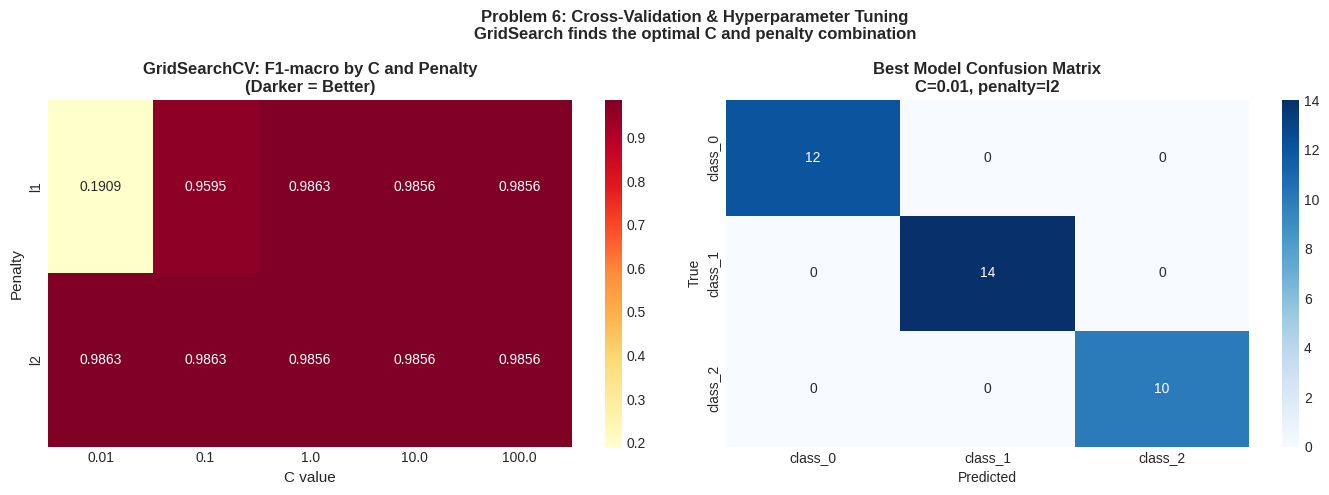

In [19]:
# ── VISUALIZATION ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GridSearch heatmap — shows F1-macro for every C × penalty combination
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(
    index='param_penalty', columns='param_C', values='mean_test_score'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('GridSearchCV: F1-macro by C and Penalty\n(Darker = Better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('C value', fontsize=11)
axes[0].set_ylabel('Penalty', fontsize=11)

# Confusion matrix of best model
cm = confusion_matrix(y_wine_te, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[1].set_title(f'Best Model Confusion Matrix\nC={grid_search.best_params_["C"]}, '
                  f'penalty={grid_search.best_params_["penalty"]}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('True', fontsize=10)

plt.suptitle('Problem 6: Cross-Validation & Hyperparameter Tuning\n'
             'GridSearch finds the optimal C and penalty combination',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary: Key scikit-learn Parameters for Logistic Regression

### `sklearn.linear_model.LogisticRegression` — Parameter Reference

| Parameter | Default | What It Controls | Recommended Setting |
|-----------|---------|-----------------|---------------------|
| `C` | 1.0 | Inverse regularization strength (1/alpha) | Tune via GridSearchCV |
| `penalty` | `'l2'` | Regularization type: 'l1', 'l2', 'elasticnet', None | 'l2' general; 'l1' for sparsity |
| `solver` | `'lbfgs'` | Optimization algorithm | See compatibility table |
| `max_iter` | 100 | Max iterations | **Always set to 1000+** |
| `class_weight` | None | Sample weighting for imbalanced classes | `'balanced'` for imbalanced data |
| `multi_class` | `'auto'` | Multi-class strategy: 'ovr', 'multinomial' | 'multinomial' for correlated classes |
| `l1_ratio` | None | ElasticNet mixing (0=L2, 1=L1) | Required when penalty='elasticnet' |
| `fit_intercept` | True | Whether to fit a bias term | Keep True unless data is centered |
| `random_state` | None | Seed for reproducibility | Set for reproducible results |

### Classification Metrics Quick Reference

| Metric | When to Use | Sensitive To |
|--------|-------------|-------------|
| Accuracy | Balanced classes | Class imbalance |
| Precision | When false positives are costly | Threshold |
| Recall | When false negatives are costly | Threshold |
| F1-Score | Balance precision and recall | Class imbalance |
| AUC-ROC | Overall discriminative ability | Not threshold-dependent |

---
**Course:** DA5401W - Data Analytics Lab  |  **Instructor:** Dr. Arun B Ayyar  |  **CONFIDENTIAL**